In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import tqdm
import sys
import os

In [3]:
from sentence_transformers import SentenceTransformer

encoding_model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
import dotenv
import os

config = dotenv.dotenv_values(".env")
replace_keys = ["JAVA_HOME", "FUSEKI_HOME"]
append_keys = ["PATH"]
for key, value in config.items():
    # append to os.environ
    if key in append_keys:
        os.environ[key] = f"{os.environ.get(key, '')}:{value}"
    elif key in replace_keys:
        os.environ[key] = value

python-dotenv could not parse statement starting at line 34
python-dotenv could not parse statement starting at line 37
python-dotenv could not parse statement starting at line 38
python-dotenv could not parse statement starting at line 40
python-dotenv could not parse statement starting at line 44
python-dotenv could not parse statement starting at line 48
python-dotenv could not parse statement starting at line 56
python-dotenv could not parse statement starting at line 57
python-dotenv could not parse statement starting at line 60
python-dotenv could not parse statement starting at line 61
python-dotenv could not parse statement starting at line 63
python-dotenv could not parse statement starting at line 64
python-dotenv could not parse statement starting at line 65
python-dotenv could not parse statement starting at line 67
python-dotenv could not parse statement starting at line 68
python-dotenv could not parse statement starting at line 71
python-dotenv could not parse statement 

In [5]:
sys.path.append(".")

In [6]:
from utils.datasets import SimpleSet, BerlinSparqlBenchmark
from utils.dbs import FusekiDB, QleverDB, BaseDB
from utils.dbs.qlever_native import QleverDBNative
from utils.dbs.fuseki_native import FusekiDBNative
from utils.datasets.base_dataset import QUERY_DIFFICULTY, QUERY_TYPE
from pathlib import Path
import numpy as np
from utils.datasets.base_dataset import DataTensor

In [7]:
powers = np.arange(0, 5)  # extend on a more powerful machine
sizes = 10**powers

In [8]:
datasets: dict[int, BerlinSparqlBenchmark] = {}
raw_sizes: dict[int, int] = {}
for power, size in zip(powers, sizes):
    print(f"Running BDSDM generation for size {size}...")
    dataset = BerlinSparqlBenchmark(base_dir=Path(f"./data/bsbm_{power}"), n=size)
    dataset.setup()
    datasets[power] = dataset
    # raw_sizes[power] = dataset.get_triple_count()

2026-03-26 17:50:10,273 - INFO - BSBM dataset already exists in data/bsbm_0, skipping generation
2026-03-26 17:50:10,273 - INFO - BSBM dataset already exists in data/bsbm_1, skipping generation
2026-03-26 17:50:10,274 - INFO - BSBM dataset already exists in data/bsbm_2, skipping generation
2026-03-26 17:50:10,274 - INFO - BSBM dataset already exists in data/bsbm_3, skipping generation
2026-03-26 17:50:10,275 - INFO - BSBM dataset already exists in data/bsbm_4, skipping generation


Running BDSDM generation for size 1...
Running BDSDM generation for size 10...
Running BDSDM generation for size 100...
Running BDSDM generation for size 1000...
Running BDSDM generation for size 10000...


In [9]:
encoded_sizes: dict[int, int] = {}
for power, size in zip(powers, sizes):
    print(f"Encoding dataset of size {size}...")
    dataset = datasets[power]
    encoded_sizes[power] = dataset.encode_streaming(encoding_model)
    #  dataset.get_triple_count(encoded=True)

Encoding dataset of size 1...
Encoded TTL file already exists at data/bsbm_0/dataset_encoded.nt, skipping encoding
Encoding dataset of size 10...
Encoded TTL file already exists at data/bsbm_1/dataset_encoded.nt, skipping encoding
Encoding dataset of size 100...
Encoded TTL file already exists at data/bsbm_2/dataset_encoded.nt, skipping encoding
Encoding dataset of size 1000...
Encoded TTL file already exists at data/bsbm_3/dataset_encoded.nt, skipping encoding
Encoding dataset of size 10000...
Encoded TTL file already exists at data/bsbm_4/dataset_encoded.nt, skipping encoding


## BSBM queries

### Simple Use case: 
find 10 products with a specific encoded label


### Complex Use case: 
For a specific product find 10 other similar products via their product label. 


In [10]:
test_label = "house furniture storage container"
test_tensor = DataTensor.from_numpy(encoding_model.encode(test_label))

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [11]:
test_tensor.to_literal().n3()

'"{\\"data\\": [0.001923849806189537, 0.059069667011499405, -0.06259278953075409, -0.008788925595581532, 0.08017760515213013, 0.0004897266626358032, 0.049011558294296265, -0.016156358644366264, -0.04537816718220711, 0.011929630301892757, -0.003551364177837968, -0.0034783161245286465, 0.023264417424798012, 0.02449001744389534, -0.023595571517944336, -0.073823943734169, 0.014226873405277729, -0.00022305997845251113, -0.03111756220459938, 0.07163400948047638, -0.04559392109513283, 0.044428009539842606, 0.0004388350062072277, -0.004044292028993368, 0.05173112079501152, 0.08436278998851776, -0.028667306527495384, -0.032494205981492996, 0.058949727565050125, -0.0051073553040623665, 0.09506019204854965, -0.029170090332627296, -0.07172352075576782, 0.036426812410354614, 0.01788988709449768, 0.07774496078491211, -0.01058284193277359, -0.02719942107796669, -0.014839782379567623, 0.004996407311409712, -0.05195301026105881, -0.01563340425491333, -0.0004883587826043367, 0.012572054751217365, -0.043

In [12]:
base_bsbm_set = datasets[2]
db = QleverDBNative(
    id="test",
    base_dir=Path(f"./scratch/bsbm/{base_bsbm_set.base_dir.name}"),
    dataset=base_bsbm_set,
    use_encoded_ttl=True,
)
db_fuseki = FusekiDBNative(
    id="test_fuseki",
    base_dir=Path(f"./scratch/bsbm/{base_bsbm_set.base_dir.name}"),
    dataset=base_bsbm_set,
    use_encoded_ttl=True,
)
possible_queries = db.get_queries(test_tensor)
print(possible_queries)


2026-03-26 17:50:10,498 - INFO - Initialized QLeverDBNative with id=test, port_id=8031, dataset=bsbm, name=QLever Native (Extended), use_encoded_ttl=True, endpoint=http://localhost:8031/test/sparql


{<QUERY_DIFFICULTY.EASY: 'easy'>: {<QUERY_TYPE.EMBEDDED: 'embedded'>: '\nPREFIX dt: <https://w3id.org/rdf-tensor/datatypes#>\nPREFIX rdf: <http://www.w3.org/2000/01/rdf-schema#>\nPREFIX dtf: <https://w3id.org/rdf-tensor/functions#>\nPREFIX bsbmi: <http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01/instances/>\nSELECT ?product  ?vector ?dist\nWHERE {\n?product rdf:label_embedding ?vector .\nBIND(dtf:cosineSimilarity(?vector, "{\\"data\\": [0.001923849806189537, 0.059069667011499405, -0.06259278953075409, -0.008788925595581532, 0.08017760515213013, 0.0004897266626358032, 0.049011558294296265, -0.016156358644366264, -0.04537816718220711, 0.011929630301892757, -0.003551364177837968, -0.0034783161245286465, 0.023264417424798012, 0.02449001744389534, -0.023595571517944336, -0.073823943734169, 0.014226873405277729, -0.00022305997845251113, -0.03111756220459938, 0.07163400948047638, -0.04559392109513283, 0.044428009539842606, 0.0004388350062072277, -0.004044292028993368, 0.05173112079501152, 0.084

In [13]:
print(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.EMBEDDED])


PREFIX dt: <https://w3id.org/rdf-tensor/datatypes#>
PREFIX rdf: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX dtf: <https://w3id.org/rdf-tensor/functions#>
PREFIX bsbmi: <http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01/instances/>
SELECT ?product  ?vector ?dist
WHERE {
?product rdf:label_embedding ?vector .
BIND(dtf:cosineSimilarity(?vector, "{\"data\": [0.001923849806189537, 0.059069667011499405, -0.06259278953075409, -0.008788925595581532, 0.08017760515213013, 0.0004897266626358032, 0.049011558294296265, -0.016156358644366264, -0.04537816718220711, 0.011929630301892757, -0.003551364177837968, -0.0034783161245286465, 0.023264417424798012, 0.02449001744389534, -0.023595571517944336, -0.073823943734169, 0.014226873405277729, -0.00022305997845251113, -0.03111756220459938, 0.07163400948047638, -0.04559392109513283, 0.044428009539842606, 0.0004388350062072277, -0.004044292028993368, 0.05173112079501152, 0.08436278998851776, -0.028667306527495384, -0.032494205981492996, 0.05894972756505012

In [14]:
import os
os.getcwd()

'/nfsd/gracedata2/kantz/Dense-Vector-KG/benchmarks'

In [15]:
with db_fuseki:
    possible_queries = db_fuseki.get_queries(test_tensor)
    results = db_fuseki.query(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.EMBEDDED])
results

2026-03-26 17:50:10,631 - INFO - Loading dataset into Fuseki server from data/bsbm_2/dataset.nt
2026-03-26 17:50:12,535 - INFO - Stopping server!
2026-03-26 17:50:12,536 - INFO - Starting Fuseki server port 7031
2026-03-26 17:50:12,537 - INFO - Using FUSEKI_HOME=None and TENSOR_CP=None
2026-03-26 17:50:12,537 - ERROR - FUSEKI_HOME environment variable is not set
2026-03-26 17:50:12,538 - INFO - Using default FUSEKI_HOME=/home/kantz/apache-jena-fuseki-5.2.0
2026-03-26 17:50:12,550 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:7031/test_fuseki/sparql)
2026-03-26 17:50:14,267 - INFO - Server is up and responding to queries
2026-03-26 17:50:14,398 - INFO - Stopping server!


,product,vector,dist
0,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.02453641965985298, -0.007929500192...",None
1,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.016603631898760796, 0.041465207934...",None
2,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.026901844888925552, -0.03566396608...",None
3,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.14625921845436096, 0.084719471633...",None
4,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.005764072295278311, 0.03636718913...",None
5,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.01215534470975399, 0.008054492995...",None
6,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.0873505100607872, 0.0104109533131...",None
7,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.06898826360702515, 0.103729203343...",None
8,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.08012410253286362, -0.041107315570...",None
9,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.08219819515943527, 0.027206031605...",None


In [16]:
import os
os.environ["PATH"]

'/nfsd/gracedata2/kantz/Dense-Vector-KG/.venv/bin:/nfsd/gracedata2/kantz/Dense-Vector-KG/.venv/bin:/nfsd/gracedata2/kantz/Dense-Vector-KG/qlever/build/release:/home/kantz/apache-jena-fuseki-5.2.0:/home/kantz/apache-jena-5.2.0/bin:/home/kantz/miniconda3/envs/qlever/bin:/home/kantz/.vscode-server/data/User/globalStorage/github.copilot-chat/debugCommand:/home/kantz/.vscode-server/data/User/globalStorage/github.copilot-chat/copilotCli:/home/kantz/.vscode-server/cli/servers/Stable-cfbea10c5ffb233ea9177d34726e6056e89913dc/server/bin/remote-cli:/home/kantz/bin:/home/kantz/bin:/home/kantz/.local/bin:/usr/share/Modules/bin:/usr/condabin:/usr/local/bin:/usr/bin:/usr/local/sbin:/usr/sbin:/usr/java/latest/bin:/usr/lib/scala/bin:/usr/local/spark-2.3.2-bin-hadoop2.7/bin:/usr/java/latest/bin:/usr/lib/scala/bin:/usr/local/spark-2.3.2-bin-hadoop2.7/bin:/home/kantz/.vscode-server/extensions/ms-python.debugpy-2025.18.0-linux-x64/bundled/scripts/noConfigScripts:/home/kantz/.vscode-server/cli/servers/Stabl

In [17]:
with db:
    count=db.query("SELECT (COUNT(*) AS ?count) WHERE { ?s ?p ?o }")
print(count)

2026-03-26 17:50:14,510 - INFO - Loading dataset into QLever server from data/bsbm_2/dataset.nt
2026-03-26 17:50:14,511 - WARNING - DB directory scratch/test/db already exists, removing locks if any
2026-03-26 17:50:14,512 - INFO - Stopping server!
2026-03-26 17:50:14,512 - INFO - Starting QLever server on port 8031
2026-03-26 17:50:14,513 - INFO - Running command: qlever-server -i test --port 8031 -k 0
2026-03-26 17:50:14,515 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:8031/test/sparql)
2026-03-26 17:50:15,531 - INFO - Server is up and responding to queries
2026-03-26 17:50:15,541 - INFO - Stopping server!


   count
0  42417


In [18]:
import time

with db:
    timings = []
    for _ in tqdm.tqdm(range(10)):
        start_time = time.time()
        results = db.query_auto(
            test_tensor, query_difficulty=QUERY_DIFFICULTY.EASY, query_type=QUERY_TYPE.EMBEDDED
        )
        elapsed_time = time.time() - start_time
        timings.append(elapsed_time)
print("Median elapsed time:", np.median(timings))
results

2026-03-26 17:50:15,606 - INFO - Loading dataset into QLever server from data/bsbm_2/dataset.nt
2026-03-26 17:50:15,619 - WARNING - DB directory scratch/test/db already exists, removing locks if any
2026-03-26 17:50:15,619 - INFO - Stopping server!
2026-03-26 17:50:15,620 - INFO - Starting QLever server on port 8031
2026-03-26 17:50:15,620 - INFO - Running command: qlever-server -i test --port 8031 -k 0
2026-03-26 17:50:15,622 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:8031/test/sparql)
2026-03-26 17:50:16,637 - INFO - Server is up and responding to queries
100%|██████████| 10/10 [00:00<00:00, 33.61it/s]
2026-03-26 17:50:16,938 - INFO - Stopping server!


Median elapsed time: 0.010347247123718262


,product,vector,dist
0,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.009423847310245037, -0.01557747554...",0.3165359795094
1,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.010077591054141521, -0.07332565635...",0.293604195118
2,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.0399559922516346, 0.04019024968147...",0.2867618203163
3,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.06109052151441574, -0.086534291505...",0.2798336446285
4,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.018030863255262375, 0.051510427147...",0.2643584012985
5,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.03998035192489624, 0.0118160368874...",0.2636927366257
6,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.07872356474399567, 0.087168984115...",0.2601968646049
7,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.0035400420892983675, 0.0261042360...",0.259198307991
8,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [-0.05134187638759613, -0.03562515974...",0.2406378090382
9,http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01...,"{""data"": [0.07709012180566788, 0.0770644396543...",0.240260347724


## Try some timings!

In [20]:
import timeit
import pandas as pd


def test_db(
    power: int,
    size: int,
    db: BaseDB,
    difficulty=QUERY_DIFFICULTY.EASY,
    query_type=QUERY_TYPE.EMBEDDED,
    repetitions=128,
) -> pd.DataFrame:
    timings = []
    if query_type not in db.get_available_query_types():
        print(f"Query type {query_type} not available for {db.name}, skipping.")
        return pd.DataFrame()
    for i in tqdm.tqdm(
        range(repetitions),
        desc=f"Timing for size {size}, difficulty {difficulty.value}, query type {query_type.value}, db {db.name}",
    ):
        # add a small amount of noise to the test tensor to avoid caching effects
        noised_tensor = DataTensor.from_numpy(
            test_tensor.data
            + np.random.normal(scale=0.001, size=test_tensor.shape)
        )

        test_queries = db.get_queries(embedding=noised_tensor)
        q = test_queries[difficulty][query_type]
        start_time = timeit.default_timer()
        try:
            results = db.raw_query(q)
            assert results is not None and len(results.bindings) > 0, (
                "Query returned no results"
            )
        except Exception as e:
            print(f"Error occurred while querying {db.name}: {e}")
            break
        end_time = timeit.default_timer()
        elapsed_time = end_time - start_time
        timings.append(
            {
                "size": encoded_sizes[power],
                "power": power,
                "estimated_size": size,
                "elapsed_time": elapsed_time,
                "rep": i,
                "engine": db.name,
                "difficulty": difficulty.value,
                "query_type": query_type.value,
            }
        )
        if elapsed_time > 30:
            print(
                f"Warning: Query took {elapsed_time:.2f} seconds on {db.name} for size {size}, difficulty {difficulty.value}, query type {query_type.value}. Will cancel."
            )
            break
    return pd.DataFrame(timings)


timings_df = pd.DataFrame()
for power, size in zip(powers, sizes):
    difficulties = [
        # QUERY_DIFFICULTY.HARD,
        QUERY_DIFFICULTY.EASY,
    ]
    if power > 1:
        difficulties = [QUERY_DIFFICULTY.EASY]
    print(f"Running BDSDM timing for size {size}...")
    dataset = datasets[power]
    dbs: list[BaseDB] = [
        QleverDBNative(
            id="timing-qlever",
            base_dir=Path(f"./scratch/bsbm/{dataset.base_dir.name}"),
            dataset=dataset,
            use_encoded_ttl=True,
        ),
        FusekiDBNative(
            id="timing-fuseki",
            base_dir=Path(f"./scratch/bsbm/{dataset.base_dir.name}"),
            dataset=dataset,
            use_encoded_ttl=True,
        ),
    ]
    for db in dbs:
        for difficulty in difficulties:
            repetitions = 16 if difficulty == QUERY_DIFFICULTY.EASY else 16
            for query_type in [
                # QUERY_TYPE.INDEX,
                QUERY_TYPE.EMBEDDED,
            ]:
                print(
                    f"Testing {db.name} with difficulty {difficulty.value} and query type {query_type.value}..."
                )
                with db:
                    db_timings = test_db(
                        power=power,
                        size=size,
                        db=db,
                        difficulty=difficulty,
                        query_type=query_type,
                        repetitions=repetitions,
                    )
                    timings_df = pd.concat([timings_df, db_timings], ignore_index=True)


2026-03-26 17:52:52,723 - INFO - Initialized QLeverDBNative with id=timing-qlever, port_id=8031, dataset=bsbm, name=QLever Native (Extended), use_encoded_ttl=True, endpoint=http://localhost:8031/timing-qlever/sparql
2026-03-26 17:52:52,724 - INFO - Loading dataset into QLever server from data/bsbm_0/dataset.nt


Running BDSDM timing for size 1...
Testing QLever Native (Extended) with difficulty easy and query type embedded...


2026-03-26 17:52:53,181 - INFO - Stopping server!
2026-03-26 17:52:53,182 - INFO - Starting QLever server on port 8031
2026-03-26 17:52:53,182 - INFO - Running command: qlever-server -i timing-qlever --port 8031 -k 0
2026-03-26 17:52:53,184 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:8031/timing-qlever/sparql)
2026-03-26 17:52:54,197 - INFO - Server is up and responding to queries
Timing for size 1, difficulty easy, query type embedded, db QLever Native (Extended): 100%|██████████| 16/16 [00:00<00:00, 18.38it/s]
2026-03-26 17:52:55,073 - INFO - Stopping server!
2026-03-26 17:52:55,074 - INFO - Loading dataset into Fuseki server from data/bsbm_0/dataset.nt


Testing FusekiDB + RDFTensor with difficulty easy and query type embedded...


2026-03-26 17:52:56,430 - INFO - Stopping server!
2026-03-26 17:52:56,431 - INFO - Starting Fuseki server port 7031
2026-03-26 17:52:56,432 - INFO - Using FUSEKI_HOME=None and TENSOR_CP=None
2026-03-26 17:52:56,432 - ERROR - FUSEKI_HOME environment variable is not set
2026-03-26 17:52:56,432 - INFO - Using default FUSEKI_HOME=/home/kantz/apache-jena-fuseki-5.2.0
2026-03-26 17:52:56,434 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:7031/timing-fuseki/sparql)
2026-03-26 17:52:58,113 - INFO - Server is up and responding to queries
Timing for size 1, difficulty easy, query type embedded, db FusekiDB + RDFTensor: 100%|██████████| 16/16 [00:00<00:00, 42.92it/s]
2026-03-26 17:52:58,489 - INFO - Stopping server!
2026-03-26 17:52:58,491 - INFO - Initialized QLeverDBNative with id=timing-qlever, port_id=8031, dataset=bsbm, name=QLever Native (Extended), use_encoded_ttl=True, endpoint=http://localhost:8031/timing-qlever/sparql

...

2026-03-26 17:53:39,234 - INFO - Stopping server!
2026-03-26 17:53:39,235 - INFO - Starting Fuseki server port 7031
2026-03-26 17:53:39,235 - INFO - Using FUSEKI_HOME=None and TENSOR_CP=None
2026-03-26 17:53:39,235 - ERROR - FUSEKI_HOME environment variable is not set
2026-03-26 17:53:39,236 - INFO - Using default FUSEKI_HOME=/home/kantz/apache-jena-fuseki-5.2.0
2026-03-26 17:53:39,240 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:7031/timing-fuseki/sparql)
2026-03-26 17:53:40,947 - INFO - Server is up and responding to queries
Timing for size 1000, difficulty easy, query type embedded, db FusekiDB + RDFTensor: 100%|██████████| 16/16 [00:00<00:00, 22.02it/s]
2026-03-26 17:53:41,677 - INFO - Stopping server!
2026-03-26 17:53:41,679 - INFO - Initialized QLeverDBNative with id=timing-qlever, port_id=8031, dataset=bsbm, name=QLever Native (Extended), use_encoded_ttl=True, endpoint=http://localhost:8031/timing-qlever/spa

Running BDSDM timing for size 10000...
Testing QLever Native (Extended) with difficulty easy and query type embedded...


2026-03-26 17:53:56,993 - INFO - Stopping server!
2026-03-26 17:53:56,994 - INFO - Starting QLever server on port 8031
2026-03-26 17:53:56,994 - INFO - Running command: qlever-server -i timing-qlever --port 8031 -k 0
2026-03-26 17:53:56,997 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:8031/timing-qlever/sparql)
2026-03-26 17:53:58,007 - INFO - Server is up and responding to queries
Timing for size 10000, difficulty easy, query type embedded, db QLever Native (Extended): 100%|██████████| 16/16 [00:56<00:00,  3.55s/it]
2026-03-26 17:54:54,827 - INFO - Stopping server!
2026-03-26 17:54:54,828 - INFO - Loading dataset into Fuseki server from data/bsbm_4/dataset.nt


Testing FusekiDB + RDFTensor with difficulty easy and query type embedded...


2026-03-26 17:55:30,804 - INFO - Stopping server!
2026-03-26 17:55:30,805 - INFO - Starting Fuseki server port 7031
2026-03-26 17:55:30,805 - INFO - Using FUSEKI_HOME=None and TENSOR_CP=None
2026-03-26 17:55:30,806 - ERROR - FUSEKI_HOME environment variable is not set
2026-03-26 17:55:30,806 - INFO - Using default FUSEKI_HOME=/home/kantz/apache-jena-fuseki-5.2.0
2026-03-26 17:55:30,808 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:7031/timing-fuseki/sparql)
2026-03-26 17:55:32,469 - INFO - Server is up and responding to queries
Timing for size 10000, difficulty easy, query type embedded, db FusekiDB + RDFTensor: 100%|██████████| 16/16 [00:01<00:00, 11.11it/s]
2026-03-26 17:55:33,912 - INFO - Stopping server!


In [30]:
db.get_queries(test_tensor)[QUERY_DIFFICULTY.EASY].keys()

dict_keys([<QUERY_TYPE.EMBEDDED: 'embedded'>, <QUERY_TYPE.TWO_STAGE: 'two_stage'>])

In [35]:
timings_df

,size,power,estimated_size,elapsed_time,rep,engine,difficulty,query_type
0,None,0,1,0.057569,0,QLever Native (Extended),easy,embedded
1,None,0,1,0.052624,1,QLever Native (Extended),easy,embedded
2,None,0,1,0.052119,2,QLever Native (Extended),easy,embedded
3,None,0,1,0.052046,3,QLever Native (Extended),easy,embedded
4,None,0,1,0.051432,4,QLever Native (Extended),easy,embedded
...,...,...,...,...,...,...,...,...
155,None,4,10000,0.056331,11,FusekiDB + RDFTensor,easy,embedded
156,None,4,10000,0.058380,12,FusekiDB + RDFTensor,easy,embedded
157,None,4,10000,0.056632,13,FusekiDB + RDFTensor,easy,embedded
158,None,4,10000,0.056176,14,FusekiDB + RDFTensor,easy,embedded


In [31]:
timings_df.to_csv("./scratch/bdsdm_timings.csv", index=False)
timings_df["engine"].unique()

<ArrowStringArray>
['QLever Native (Extended)', 'FusekiDB + RDFTensor']
Length: 2, dtype: str

In [32]:
engines = timings_df["engine"].unique()
difficulties = timings_df["difficulty"].unique()

In [36]:
groupings = timings_df.groupby(["estimated_size", "engine", "difficulty", "query_type"])[
    "elapsed_time"
]
quantiles = [0.05, 0.95]
median_timings = groupings.median().reset_index()
quantile_timings = groupings.quantile(quantiles).unstack().reset_index()

In [37]:
colors = {eng: color for eng, color in zip(engines, ["C0", "C1", "C2", "C3", "C4"])}
colors

{'QLever Native (Extended)': 'C0', 'FusekiDB + RDFTensor': 'C1'}

/tmp/ipykernel_788093/421834132.py:22: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(


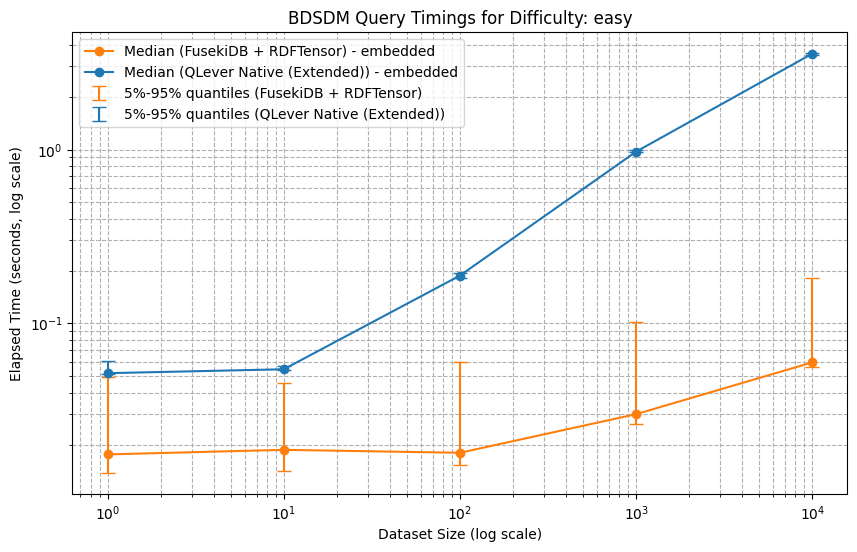

In [39]:
import matplotlib.pyplot as plt


# plot the timings as double-log plot with error bars for the 5% and 95% quantiles
def plot_timings(ax, median_timings, quantile_timings, engine, difficulty):
    for query_type in QUERY_TYPE:
        for engine in median_timings["engine"].unique():
            engine_median = median_timings[
                (median_timings["query_type"] == query_type.value)
                & (median_timings["difficulty"] == difficulty)
                & (median_timings["engine"] == engine)
            ]
            engine_quantiles = quantile_timings[
                (quantile_timings["query_type"] == query_type.value)
                & (quantile_timings["difficulty"] == difficulty)
                & (quantile_timings["engine"] == engine)
            ]
            if engine_median.empty or engine_quantiles.empty:
                continue
            # index are dashed, embedded are solid
            linestyle = "--" if query_type == QUERY_TYPE.INDEX else "-"
            ax.plot(
                engine_median["estimated_size"],
                engine_median["elapsed_time"],
                "o-",
                linestyle=linestyle,
                label=f"Median ({engine}) - {query_type.value}",
                color=colors[engine],
            )
            ax.errorbar(
                engine_median["estimated_size"],
                engine_median["elapsed_time"],
                yerr=[
                    engine_median["elapsed_time"] - engine_quantiles[0.05],
                    engine_quantiles[0.95] - engine_median["elapsed_time"],
                ],
                barsabove=True,
                capsize=5,
                fmt="none",
                label=f"5%-95% quantiles ({engine})",
                color=colors[engine],
            )


fig, axes = plt.subplots(len(difficulties), 1, figsize=(10, 6 * len(difficulties)))
for i, difficulty in enumerate(difficulties):
    ax = axes[i] if len(difficulties) > 1 else axes
    # set the subtitle to the difficulty

    plot_timings(ax, median_timings, quantile_timings, engines, difficulty)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Dataset Size (log scale)")
    ax.set_ylabel("Elapsed Time (seconds, log scale)")
    ax.set_title(f"BDSDM Query Timings for Difficulty: {difficulty}")
    ax.legend()
    ax.grid(True, which="both", ls="--")
plt.savefig("./scratch/bdsdm_timings.png")
plt.show()

In [28]:
import numpy as np
import faiss

N = 10000
quantizer = faiss.IndexFlatIP(N)  # the other index
index = faiss.IndexIVFFlat(quantizer, N, 100)
data = []
for i in range(N):
    vec = np.zeros(N, dtype=np.float32) + 0.001 * np.random.rand(N)
    vec[i] = 1.0
    data.append(vec)
data = np.array(data)
index.train(data)
index.add(data)

ModuleNotFoundError: No module named 'faiss'

In [ ]:
query_vec = np.zeros(N, dtype=np.float32)
query_vec[12] = 1.0
D, I = index.search(query_vec[None, :], 100)
print("Distances:", D)
print("Indices:", I)

Distances: [[0.00334409 2.0013294  2.0013456  2.0013587  2.0013864  2.0013967
  2.0014403  2.001448   2.0014603  2.001493   2.001494   2.0014982
  2.0015168  2.0015302  2.0015624  2.0015633  2.0015686  2.00162
  2.001625   2.0016418  2.0016465  2.0016527  2.0016606  2.001687
  2.0016973  2.0017102  2.0017114  2.0017352  2.0017376  2.0017383
  2.001806   2.0018067  2.0018392  2.0018516  2.0018554  2.0018783
  2.0018864  2.0018933  2.0018942  2.0019245  2.0019312  2.0019438
  2.0019631  2.001964   2.0019727  2.0020366  2.0020516  2.002059
  2.0020745  2.002081   2.0020893  2.002124   2.0021417  2.0021632
  2.00219    2.0021968  2.0022275  2.00223    2.0022318  2.002242
  2.0022457  2.002248   2.0022888  2.0022984  2.0022998  2.0023062
  2.0023408  2.00236    2.0023608  2.0023642  2.0023665  2.0023918
  2.002412   2.002434   2.0024385  2.0024424  2.0024424  2.0025005
  2.0025434  2.002547   2.0025501  2.0025568  2.0025716  2.0025926
  2.002597   2.0026052  2.002614   2.0026255  2.0026276 